# Confidence Interval Analysis for CVD Counterfactuals

This notebook runs the counterfactual analysis 100 times and computes confidence intervals for all metrics.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from dowhy import gcm
from dowhy.gcm.util.general import set_random_seed

from dataLoader import DataLoader
from confidence_interval_analysis import ConfidenceIntervalAnalyzer

import warnings
warnings.filterwarnings('ignore')

c:\Users\pmkul\.conda\envs\mtech-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load and Prepare Data

In [2]:
# Load data
loader = DataLoader('heart_statlog_cleveland_hungary_final.csv')
df = loader.load_data()

# Remove outliers (choose your preferred method)
df_clean = loader.remove_outliers_iqr(df)

print(f"Original data shape: {df.shape}")
print(f"Clean data shape: {df_clean.shape}")
print(f"\nData preview:")
df_clean.head()

Data loaded successfully.
Original data shape: (746, 12)
Clean data shape: (707, 12)

Data preview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
2,37,1,2,130,283,0,1,98,0,0.0,1,0
4,54,1,3,150,195,0,0,122,0,0.0,1,0
5,39,1,3,120,339,0,0,170,0,0.0,1,0
6,45,0,2,130,237,0,0,170,0,0.0,1,0


## Step 2: Build and Fit Causal Model

Define your causal graph based on domain knowledge.

In [3]:
# Define causal graph
# This is an example - adjust based on your domain knowledge
causal_graph = nx.DiGraph([
    # Demographics -> Risk factors
    ('age', 'trestbps'),
    ('age', 'chol'),
    ('age', 'thalach'),
    ('sex', 'trestbps'),
    ('sex', 'chol'),
    
    # Risk factors -> Symptoms
    ('trestbps', 'cp'),
    ('chol', 'cp'),
    ('trestbps', 'restecg'),
    ('thalach', 'exang'),
    ('thalach', 'oldpeak'),
    
    # Everything -> Target
    ('age', 'target'),
    ('sex', 'target'),
    ('cp', 'target'),
    ('trestbps', 'target'),
    ('chol', 'target'),
    ('fbs', 'target'),
    ('restecg', 'target'),
    ('thalach', 'target'),
    ('exang', 'target'),
    ('oldpeak', 'target'),
    ('slope', 'target'),
])

print(f"Causal graph has {causal_graph.number_of_nodes()} nodes and {causal_graph.number_of_edges()} edges")

Causal graph has 12 nodes and 21 edges


In [4]:
# Create and fit causal model
set_random_seed(42)

causal_model = gcm.StructuralCausalModel(causal_graph)

# Auto-assign causal mechanisms
gcm.auto.assign_causal_mechanisms(causal_model, df_clean)

# Fit the model
print("Fitting causal model...")
gcm.fit(causal_model, df_clean)
print("Causal model fitted successfully!")

Fitting causal model...


Fitting causal mechanism of node slope: 100%|██████████| 12/12 [00:00<00:00, 28.96it/s] 

Causal model fitted successfully!


## Step 3: Run Confidence Interval Analysis

This will run the counterfactual analysis 100 times with different random seeds.

In [5]:
# Create CI analyzer
ci_analyzer = ConfidenceIntervalAnalyzer(
    causal_model=causal_model,
    n_runs=100,  # Number of bootstrap iterations
    confidence_level=0.95  # 95% confidence intervals
)

print("Starting bootstrap analysis...")
print("This may take several minutes...\n")

Starting bootstrap analysis...
This may take several minutes...



In [6]:
# Run the analysis
ci_analyzer.run_bootstrap_analysis()

Running 100 iterations of counterfactual analysis...
Confidence level: 95.0%



Bootstrap iterations:   0%|          | 0/100 [00:00<?, ?it/s]


Processing instance 0

Processing instance 1

Processing instance 2

Processing instance 3

Processing instance 4

Processing instance 5

Processing instance 6

Processing instance 7

Processing instance 8

Processing instance 9

Processing instance 10

Processing instance 11

Processing instance 12

Processing instance 13

Processing instance 14

Processing instance 15

Processing instance 16

Processing instance 17

Processing instance 18

Processing instance 19

Processing instance 20

Processing instance 21

Processing instance 22

Processing instance 23

Processing instance 24

Processing instance 25

Processing instance 26

Processing instance 27

Processing instance 28

Processing instance 29

Processing instance 30

Processing instance 31

Processing instance 32

Processing instance 33

Processing instance 34

Processing instance 35

Processing instance 36

Processing instance 37

Processing instance 38

Processing instance 39

Processing instance 40

Processing instance 41

P

Bootstrap iterations:   1%|          | 1/100 [00:04<06:49,  4.13s/it]


COUNTERFACTUAL ANALYSIS SUMMARY
Total instances processed: 48
Instances with counterfactuals: 48
Failed instances: 0
Total counterfactuals generated: 239
Working counterfactuals (target=0): 30
Processing time: 4.06 seconds

Distance metrics for all counterfactuals:
       euclidean_distance  manhattan_distance
count          239.000000          239.000000
mean             1.163180            1.163180
std              0.856601            0.856601
min              0.000000            0.000000
25%              0.000000            0.000000
50%              1.000000            1.000000
75%              2.000000            2.000000
max              3.000000            3.000000

Distance metrics for working counterfactuals:
       euclidean_distance  manhattan_distance
count           30.000000           30.000000
mean             1.700000            1.700000
std              0.466092            0.466092
min              1.000000            1.000000
25%              1.000000            1.000

...


Processing instance 47

COUNTERFACTUAL ANALYSIS SUMMARY
Total instances processed: 48
Instances with counterfactuals: 48
Failed instances: 0
Total counterfactuals generated: 239
Working counterfactuals (target=0): 28
Processing time: 3.11 seconds

Distance metrics for all counterfactuals:
       euclidean_distance  manhattan_distance
count          239.000000          239.000000
mean             1.133891            1.133891
std              0.878586            0.878586
min              0.000000            0.000000
25%              0.000000            0.000000
50%              1.000000            1.000000
75%              2.000000            2.000000
max              3.000000            3.000000

Distance metrics for working counterfactuals:
       euclidean_distance  manhattan_distance
count           28.000000           28.000000
mean             1.714286            1.714286
std              0.460044            0.460044
min              1.000000            1.000000
25%              1

Bootstrap iterations:  99%|█████████▉| 99/100 [05:10<00:02,  2.84s/it]


COUNTERFACTUAL ANALYSIS SUMMARY
Total instances processed: 48
Instances with counterfactuals: 48
Failed instances: 0
Total counterfactuals generated: 239
Working counterfactuals (target=0): 27
Processing time: 2.76 seconds

Distance metrics for all counterfactuals:
       euclidean_distance  manhattan_distance
count          239.000000          239.000000
mean             1.146444            1.146444
std              0.829788            0.829788
min              0.000000            0.000000
25%              0.000000            0.000000
50%              1.000000            1.000000
75%              2.000000            2.000000
max              3.000000            3.000000

Distance metrics for working counterfactuals:
       euclidean_distance  manhattan_distance
count           27.000000           27.000000
mean             1.592593            1.592593
std              0.500712            0.500712
min              1.000000            1.000000
25%              1.000000            1.000

Bootstrap iterations: 100%|██████████| 100/100 [05:13<00:00,  3.13s/it]


Processing instance 46

Processing instance 47

COUNTERFACTUAL ANALYSIS SUMMARY
Total instances processed: 48
Instances with counterfactuals: 48
Failed instances: 0
Total counterfactuals generated: 239
Working counterfactuals (target=0): 30
Processing time: 2.76 seconds

Distance metrics for all counterfactuals:
       euclidean_distance  manhattan_distance
count          239.000000          239.000000
mean             1.196653            1.196653
std              0.819298            0.819298
min              0.000000            0.000000
25%              1.000000            1.000000
50%              1.000000            1.000000
75%              2.000000            2.000000
max              3.000000            3.000000

Distance metrics for working counterfactuals:
       euclidean_distance  manhattan_distance
count           30.000000           30.000000
mean             1.700000            1.700000
std              0.466092            0.466092
min              1.000000            1.0

## Step 4: Calculate and Save Confidence Intervals

In [7]:
# Calculate confidence intervals
ci_results = ci_analyzer.calculate_confidence_intervals()

# Save to CSV
ci_results.to_csv('confidence_intervals.csv', index=False)
print("Confidence intervals saved to confidence_intervals.csv")

# Display results
ci_results

Confidence intervals saved to confidence_intervals.csv


,metric,mean,std,median,min,max,ci_lower_t,ci_upper_t,ci_width_t,ci_lower_percentile,ci_upper_percentile,ci_width_percentile,n_runs
0,total_cf,239.000000,0.000000,239.000000,239.000000,239.000000,NaN,NaN,NaN,239.000000,239.000000,0.000000,100
1,working_cf,28.390000,3.004693,29.000000,19.000000,37.000000,27.793804,28.986196,1.192393,23.000000,33.000000,10.000000,100
2,success_rate,0.118787,0.012572,0.121339,0.079498,0.154812,0.116292,0.121281,0.004989,0.096234,0.138075,0.041841,100
3,euclidean_mean_all,1.174686,0.054256,1.171548,1.037657,1.317992,1.163921,1.185452,0.021531,1.073117,1.284937,0.211820,100
4,euclidean_std_all,0.834827,0.025179,0.835531,0.767950,0.886792,0.829831,0.839823,0.009992,0.781785,0.880014,0.098229,100
5,euclidean_median_all,1.000000,0.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,100
6,manhattan_mean_all,1.174686,0.054256,1.171548,1.037657,1.317992,1.163921,1.185452,0.021531,1.073117,1.284937,0.211820,100
7,manhattan_std_all,0.834827,0.025179,0.835531,0.767950,0.886792,0.829831,0.839823,0.009992,0.781785,0.880014,0.098229,100
8,manhattan_median_all,1.000000,0.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,100
9,euclidean_mean_working,1.707799,0.079824,1.709677,1.516129,1.892857,1.691960,1.723638,0.031678,1.548264,1.866741,0.318477,100


## Step 5: Print Summary

In [8]:
# Print formatted summary
ci_analyzer.print_summary()


CONFIDENCE INTERVAL ANALYSIS SUMMARY
Number of runs: 100
Confidence level: 95.0%

KEY METRICS WITH CONFIDENCE INTERVALS:
--------------------------------------------------------------------------------

total_cf:
  Mean: 239.0000
  Std:  0.0000
  95% CI (t-dist):      [nan, nan]
  95% CI (percentile):  [239.0000, 239.0000]

working_cf:
  Mean: 28.3900
  Std:  3.0047
  95% CI (t-dist):      [27.7938, 28.9862]
  95% CI (percentile):  [23.0000, 33.0000]

success_rate:
  Mean: 0.1188
  Std:  0.0126
  95% CI (t-dist):      [0.1163, 0.1213]
  95% CI (percentile):  [0.0962, 0.1381]

euclidean_mean_working:
  Mean: 1.7078
  Std:  0.0798
  95% CI (t-dist):      [1.6920, 1.7236]
  95% CI (percentile):  [1.5483, 1.8667]

manhattan_mean_working:
  Mean: 1.7078
  Std:  0.0798
  95% CI (t-dist):      [1.6920, 1.7236]
  95% CI (percentile):  [1.5483, 1.8667]

euclidean_median_working:
  Mean: 2.0000
  Std:  0.0000
  95% CI (t-dist):      [nan, nan]
  95% CI (percentile):  [2.0000, 2.0000]

manhattan

## Step 6: Visualize Key Metrics

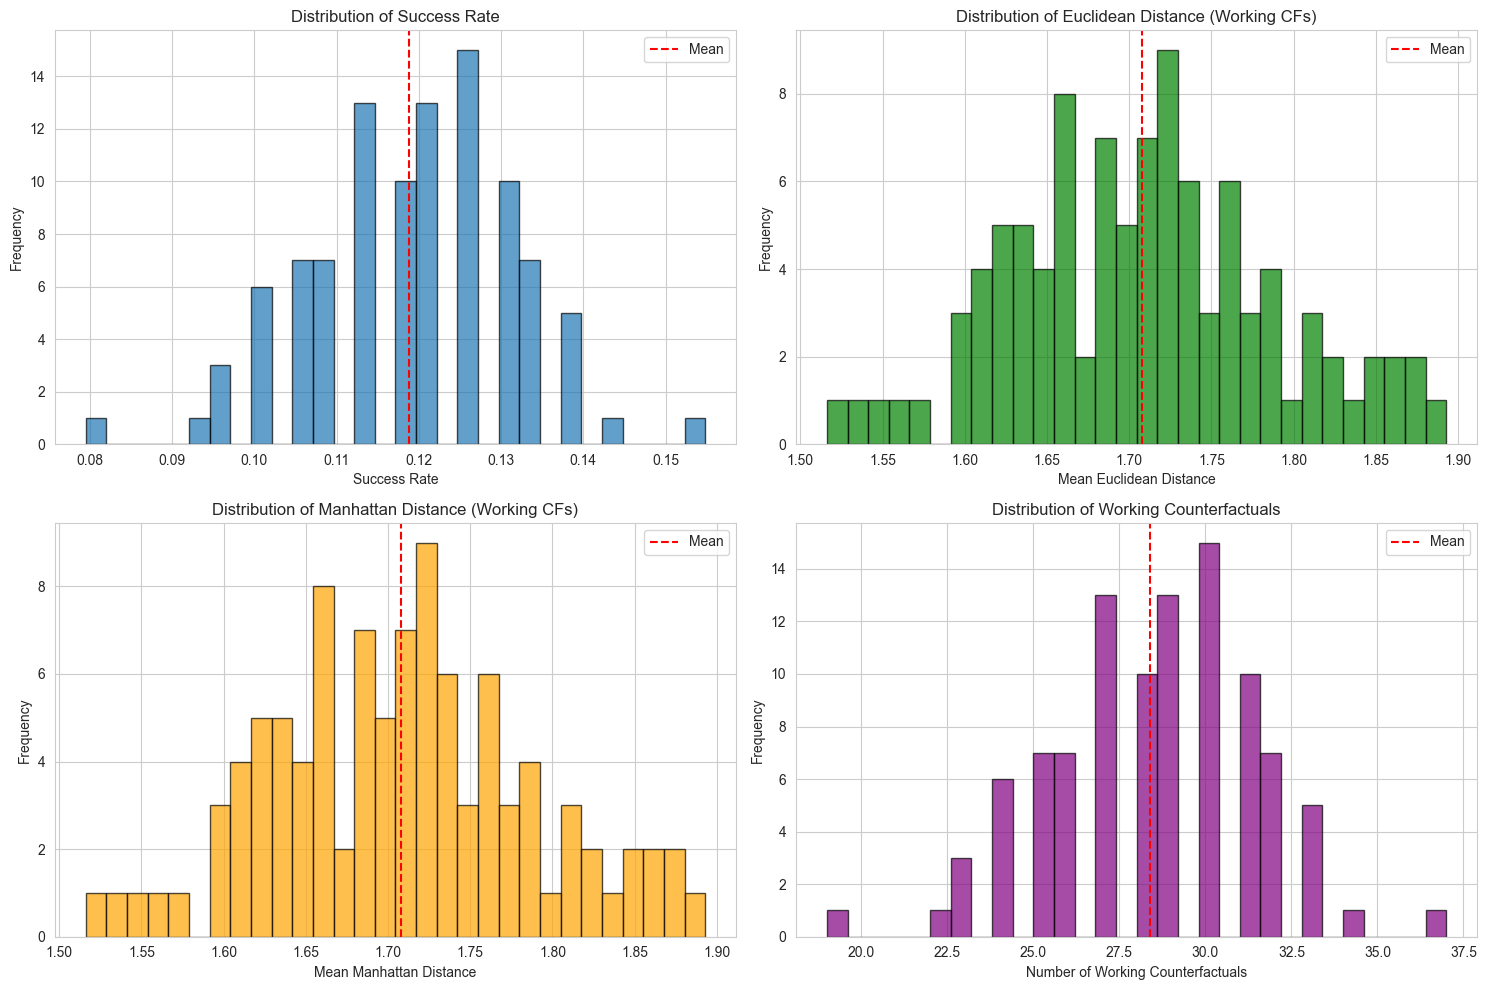

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Get metrics across all runs
metrics_df = pd.DataFrame(ci_analyzer.metrics_per_run)

# Plot key metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Success rate
axes[0, 0].hist(metrics_df['success_rate'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(metrics_df['success_rate'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].set_xlabel('Success Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Success Rate')
axes[0, 0].legend()

# Euclidean distance (working)
axes[0, 1].hist(metrics_df['euclidean_mean_working'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].axvline(metrics_df['euclidean_mean_working'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].set_xlabel('Mean Euclidean Distance')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Euclidean Distance (Working CFs)')
axes[0, 1].legend()

# Manhattan distance (working)
axes[1, 0].hist(metrics_df['manhattan_mean_working'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(metrics_df['manhattan_mean_working'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].set_xlabel('Mean Manhattan Distance')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Manhattan Distance (Working CFs)')
axes[1, 0].legend()

# Number of working counterfactuals
axes[1, 1].hist(metrics_df['working_cf'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(metrics_df['working_cf'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].set_xlabel('Number of Working Counterfactuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Working Counterfactuals')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('confidence_interval_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 7: Confidence Interval Plots

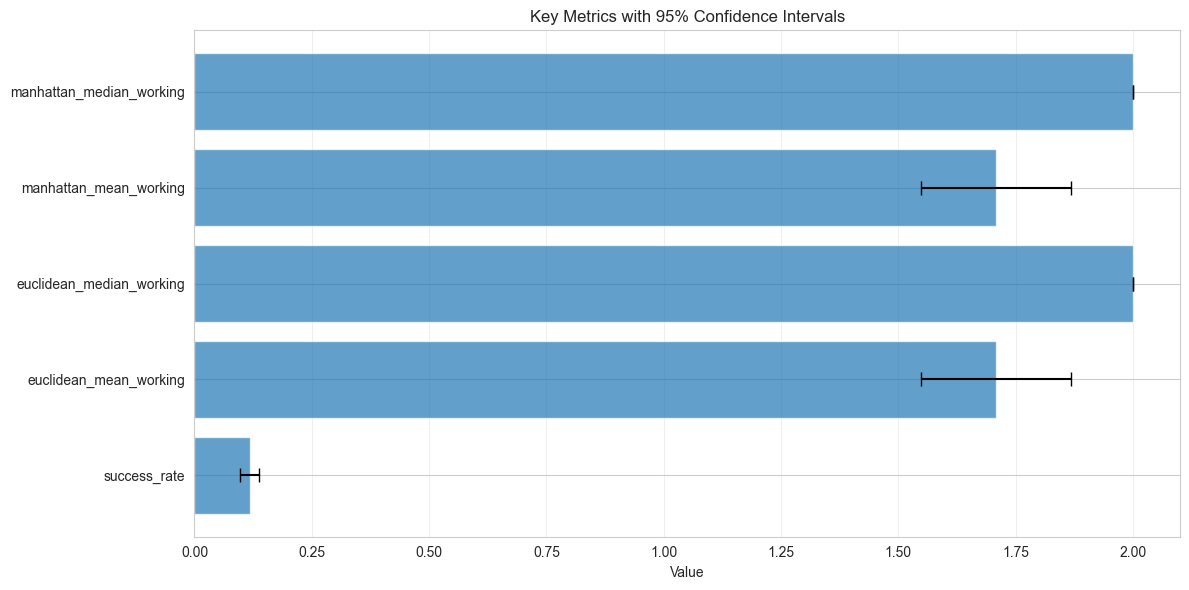

In [10]:
# Plot confidence intervals for key metrics
key_metrics = [
    'success_rate',
    'euclidean_mean_working',
    'manhattan_mean_working',
    'euclidean_median_working',
    'manhattan_median_working'
]

ci_subset = ci_results[ci_results['metric'].isin(key_metrics)]

fig, ax = plt.subplots(figsize=(12, 6))

y_pos = np.arange(len(ci_subset))
means = ci_subset['mean'].values
ci_lower = ci_subset['ci_lower_percentile'].values
ci_upper = ci_subset['ci_upper_percentile'].values
errors = np.array([means - ci_lower, ci_upper - means])

ax.barh(y_pos, means, xerr=errors, align='center', alpha=0.7, capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(ci_subset['metric'].values)
ax.set_xlabel('Value')
ax.set_title('Key Metrics with 95% Confidence Intervals')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('confidence_intervals_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 8: Feature Change Analysis

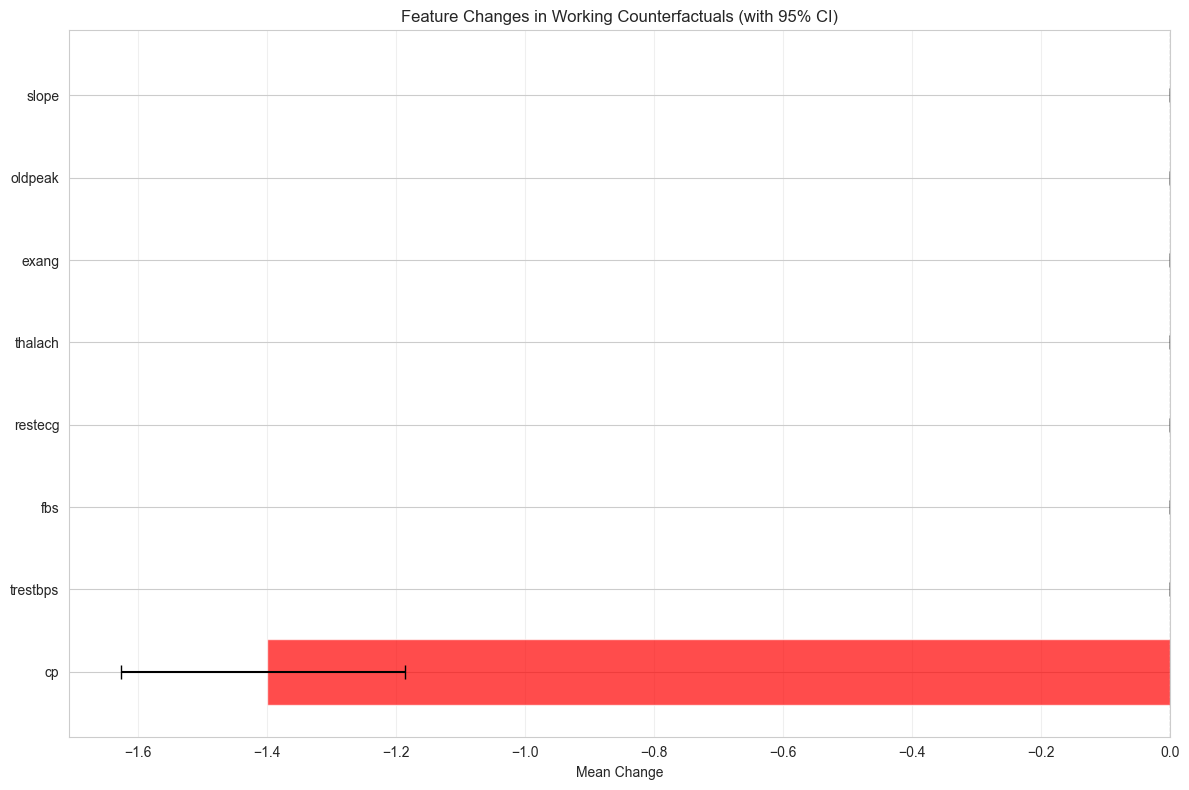


Feature Changes Summary:
 feature      mean  ci_lower_percentile  ci_upper_percentile
      cp -1.399152            -1.625383            -1.185185
trestbps  0.000000             0.000000             0.000000
     fbs  0.000000             0.000000             0.000000
 restecg  0.000000             0.000000             0.000000
 thalach  0.000000             0.000000             0.000000
   exang  0.000000             0.000000             0.000000
 oldpeak  0.000000             0.000000             0.000000
   slope  0.000000             0.000000             0.000000


In [11]:
# Extract feature change metrics
change_metrics = ci_results[ci_results['metric'].str.startswith('change_') & 
                           ci_results['metric'].str.endswith('_mean')].copy()

change_metrics['feature'] = change_metrics['metric'].str.replace('change_', '').str.replace('_mean', '')

# Plot feature changes with confidence intervals
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(change_metrics))
means = change_metrics['mean'].values
ci_lower = change_metrics['ci_lower_percentile'].values
ci_upper = change_metrics['ci_upper_percentile'].values
errors = np.array([means - ci_lower, ci_upper - means])

colors = ['red' if m < 0 else 'green' for m in means]

ax.barh(y_pos, means, xerr=errors, align='center', alpha=0.7, capsize=5, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(change_metrics['feature'].values)
ax.set_xlabel('Mean Change')
ax.set_title('Feature Changes in Working Counterfactuals (with 95% CI)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_changes_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature Changes Summary:")
print(change_metrics[['feature', 'mean', 'ci_lower_percentile', 'ci_upper_percentile']].to_string(index=False))

## Step 9: Export Summary Report

In [12]:
# Create a summary report
with open('confidence_interval_report.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("CONFIDENCE INTERVAL ANALYSIS REPORT\n")
    f.write("CVD Counterfactual Analysis\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Number of bootstrap runs: {ci_analyzer.n_runs}\n")
    f.write(f"Confidence level: {ci_analyzer.confidence_level * 100}%\n")
    f.write(f"Number of instances: 48\n\n")
    
    f.write("="*80 + "\n")
    f.write("KEY METRICS\n")
    f.write("="*80 + "\n\n")
    
    for metric in key_metrics:
        row = ci_results[ci_results['metric'] == metric]
        if not row.empty:
            row = row.iloc[0]
            f.write(f"{metric}:\n")
            f.write(f"  Mean: {row['mean']:.4f}\n")
            f.write(f"  Std:  {row['std']:.4f}\n")
            f.write(f"  95% CI: [{row['ci_lower_percentile']:.4f}, {row['ci_upper_percentile']:.4f}]\n")
            f.write(f"  CI Width: {row['ci_width_percentile']:.4f}\n\n")
    
    f.write("="*80 + "\n")
    f.write("FEATURE CHANGES (Working Counterfactuals)\n")
    f.write("="*80 + "\n\n")
    
    for _, row in change_metrics.iterrows():
        f.write(f"{row['feature']}:\n")
        f.write(f"  Mean change: {row['mean']:.4f}\n")
        f.write(f"  95% CI: [{row['ci_lower_percentile']:.4f}, {row['ci_upper_percentile']:.4f}]\n\n")

print("Summary report saved to confidence_interval_report.txt")

Summary report saved to confidence_interval_report.txt
